# Customer Churn Prediction — ML Model Comparison

**Author:** Tharun Kumar Srinivasan  
**GitHub:** https://github.com/Tharun-Design  
**Dataset:** Telco Customer Churn (Kaggle)

---

### Objective
Compare 5 machine learning models to predict customer churn.  
Select the best model based on ROC-AUC, then explain predictions using SHAP.

### Table of Contents
1. Setup and Load Data
2. Feature Engineering and Preprocessing
3. Train-Test Split and Imputation
4. Train 5 Models
5. Model Comparison and Selection
6. Best Model Deep Evaluation
7. ROC Curve Comparison
8. SHAP Explainability
9. Save Best Model
10. Summary and Recommendations

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import sys
sys.path.append('..')
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

BRAND = {
    'dark':    '#0d3b2e',
    'primary': '#1a7f5a',
    'accent':  '#4eca7f',
    'danger':  '#c0392b',
    'warning': '#d68910',
    'neutral': '#2e86ab',
    'purple':  '#6639ba',
}
PALETTE = list(BRAND.values())

print('All libraries loaded successfully')

All libraries loaded successfully


In [2]:
df = pd.read_csv('../data/cleaned/telco_churn_cleaned.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nChurn distribution:')
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
df.head()

Dataset shape: (7043, 23)

Churn distribution:
Churn
0    73.5%
1    26.5%
Name: proportion, dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,num_services
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 months,29.85,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,24-48 months,55.57,4
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 months,54.08,4
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-48 months,40.91,4
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 months,75.83,2


## 2. Feature Engineering and Preprocessing

In [3]:
TARGET   = 'Churn'
DROP_COLS = ['tenure_group']
df_ml    = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df_ml.select_dtypes(include=np.number).columns if c != TARGET]

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical columns   ({len(num_cols)}): {num_cols}')

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns   (6): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'num_services']


In [4]:
df_encoded     = df_ml.copy()
label_encoders = {}
le             = LabelEncoder()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')
print(f'Churn    : {y.sum():,} ({y.mean()*100:.1f}%)')
print('Encoding complete')

Features : 21
Samples  : 7,043
Churn    : 1,869 (26.5%)
Encoding complete


## 3. Train-Test Split and Imputation

In [5]:
# Stratified split — preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute NaN (caused by avg_monthly_spend on 0-tenure customers)
imputer         = SimpleImputer(strategy='median')
X_train_imp     = imputer.fit_transform(X_train)
X_test_imp      = imputer.transform(X_test)

X_train_clean   = pd.DataFrame(X_train_imp, columns=X.columns, index=y_train.index)
X_test_clean    = pd.DataFrame(X_test_imp,  columns=X.columns, index=y_test.index)

# Scale for models that require it (LR, SVM)
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_clean)
X_test_scaled   = scaler.transform(X_test_clean)

print(f'Train : {X_train_clean.shape[0]:,} samples  |  Churn: {y_train.mean()*100:.1f}%')
print(f'Test  : {X_test_clean.shape[0]:,}  samples  |  Churn: {y_test.mean()*100:.1f}%')
print(f'NaN check — Train: {X_train_clean.isnull().sum().sum()}  Test: {X_test_clean.isnull().sum().sum()}')
print('Ready for training')

Train : 5,634 samples  |  Churn: 26.5%
Test  : 1,409  samples  |  Churn: 26.5%
NaN check — Train: 0  Test: 0
Ready for training


## 4. Train 5 Models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,
        eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=0.05, num_leaves=50,
        class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'SVM': SVC(
        kernel='rbf', C=1.5,
        class_weight='balanced',
        probability=True, random_state=42
    )
}

# LR and SVM need scaled data
scaled_models  = {'Logistic Regression', 'SVM'}
results        = []
trained_models = {}

print('Training models...\n')
for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train_clean
    Xte = X_test_scaled  if name in scaled_models else X_test_clean

    model.fit(Xtr, y_train)
    y_pred       = model.predict(Xte)
    y_pred_prob  = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred)       * 100, 2),
        'Precision': round(precision_score(y_test, y_pred)      * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred)         * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred)             * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_prob)   * 100, 2)
    })
    trained_models[name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'y_pred_prob' : y_pred_prob
    }
    print(f'{name:<25}  Accuracy: {results[-1]["Accuracy"]}%   F1: {results[-1]["F1 Score"]}%   ROC-AUC: {results[-1]["ROC-AUC"]}%')

print('\nAll models trained successfully')

Training models...

Logistic Regression        Accuracy: 73.81%   F1: 61.76%   ROC-AUC: 83.99%
Random Forest              Accuracy: 77.0%   F1: 61.7%   ROC-AUC: 84.12%
XGBoost                    Accuracy: 75.87%   F1: 61.88%   ROC-AUC: 83.44%
LightGBM                   Accuracy: 75.94%   F1: 61.78%   ROC-AUC: 83.54%
SVM                        Accuracy: 74.24%   F1: 61.09%   ROC-AUC: 81.66%

All models trained successfully


## 5. Model Comparison and Selection

In [7]:
# Sort by ROC-AUC — primary metric for churn (imbalanced classification)
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

# Dynamically pick best model
best_row    = results_df.iloc[0]
best_name   = best_row['Model']
best_info   = trained_models[best_name]
best_model  = best_info['model']
y_pred      = best_info['y_pred']
y_pred_prob = best_info['y_pred_prob']
runner_up   = results_df.iloc[1]

print('MODEL COMPARISON RESULTS  (sorted by ROC-AUC)')
print('=' * 65)
print(results_df.to_string())
print(f'\nBest Model  : {best_name}')
print(f'ROC-AUC     : {best_row["ROC-AUC"]}%')
print(f'F1 Score    : {best_row["F1 Score"]}%')
print(f'Accuracy    : {best_row["Accuracy"]}%')
print(f'Runner-up   : {runner_up["Model"]} (ROC-AUC: {runner_up["ROC-AUC"]}%)')

MODEL COMPARISON RESULTS  (sorted by ROC-AUC)
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1        Random Forest     77.00      55.30   69.79     61.70    84.12
2  Logistic Regression     73.81      50.42   79.68     61.76    83.99
3             LightGBM     75.94      53.41   73.26     61.78    83.54
4              XGBoost     75.87      53.28   73.80     61.88    83.44
5                  SVM     74.24      50.98   76.20     61.09    81.66

Best Model  : Random Forest
ROC-AUC     : 84.12%
F1 Score    : 61.7%
Accuracy    : 77.0%
Runner-up   : Logistic Regression (ROC-AUC: 83.99%)


In [8]:
# Model selection rationale
print('MODEL SELECTION RATIONALE')
print('=' * 55)
print(f"""
Primary Metric : ROC-AUC
  Measures how well the model RANKS customers by churn
  risk. The retention team contacts a fixed number of
  customers — ranking accuracy determines campaign ROI.

Winner         : {best_name}
  ROC-AUC  : {best_row['ROC-AUC']}%  (best at ranking churn risk)
  Accuracy : {best_row['Accuracy']}%
  Precision: {best_row['Precision']}%  (fewest false alerts)
  F1 Score : {best_row['F1 Score']}%

Runner-up      : {runner_up['Model']}
  ROC-AUC gap  : {round(best_row['ROC-AUC'] - runner_up['ROC-AUC'], 2)}%
""")

MODEL SELECTION RATIONALE

Primary Metric : ROC-AUC
  Measures how well the model RANKS customers by churn
  risk. The retention team contacts a fixed number of
  customers — ranking accuracy determines campaign ROI.

Winner         : Random Forest
  ROC-AUC  : 84.12%  (best at ranking churn risk)
  Accuracy : 77.0%
  Precision: 55.3%  (fewest false alerts)
  F1 Score : 61.7%

Runner-up      : Logistic Regression
  ROC-AUC gap  : 0.13%



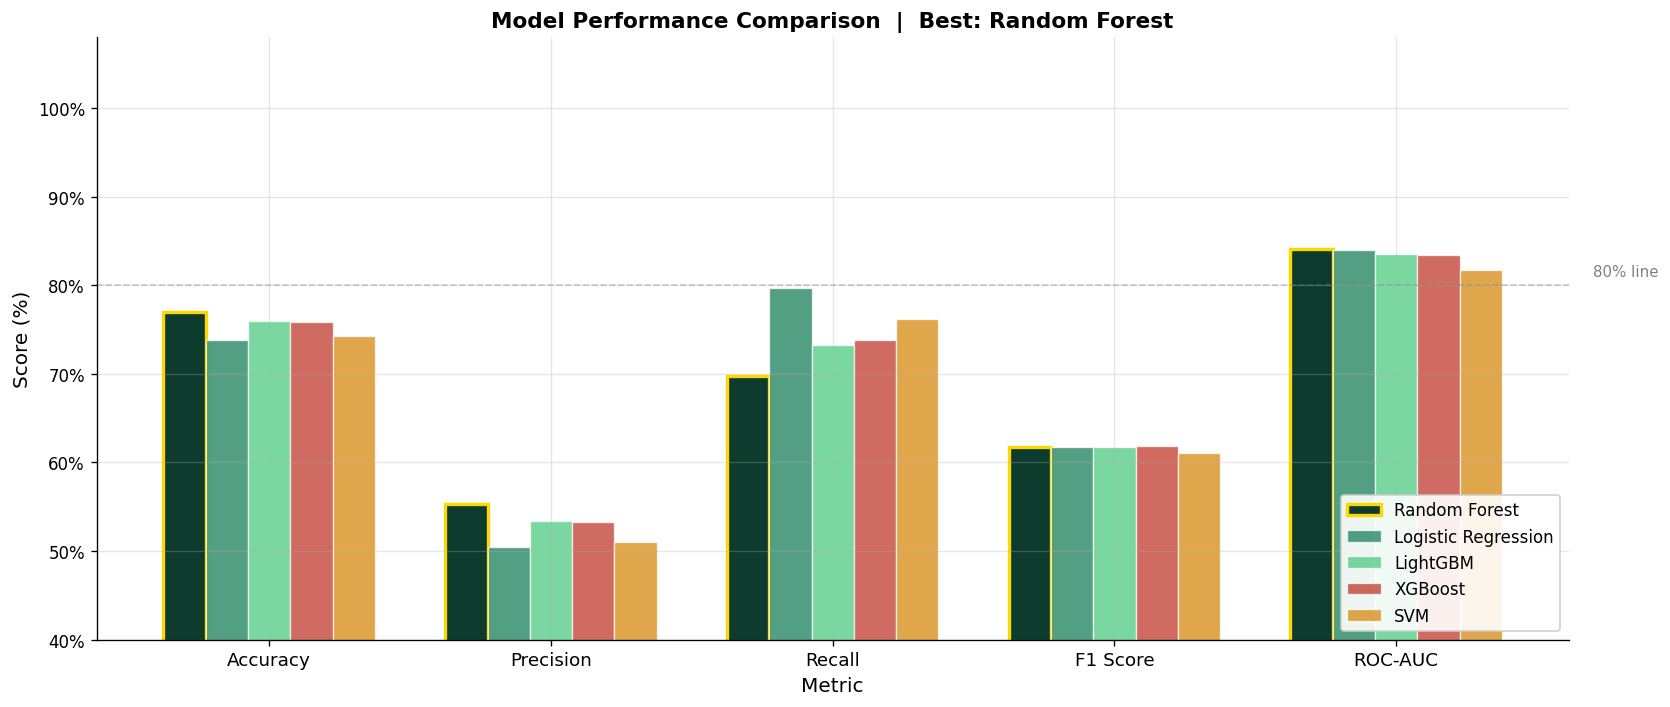

Saved: docs/model_comparison.png


In [9]:
# Grouped bar chart — all metrics, best model highlighted
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
n_models = len(results_df)
x        = np.arange(len(metrics))
width    = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals   = [row[m] for m in metrics]
    offset = (i - n_models / 2) * width + width / 2
    is_best = row['Model'] == best_name
    ax.bar(x + offset, vals, width,
           label=row['Model'],
           color=PALETTE[i % len(PALETTE)],
           alpha=1.0 if is_best else 0.75,
           edgecolor='gold' if is_best else 'white',
           linewidth=2.0 if is_best else 0.8)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title(f'Model Performance Comparison  |  Best: {best_name}',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(40, 108)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(loc='lower right', framealpha=0.9, fontsize=10)
ax.axhline(80, color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax.text(len(metrics) - 0.3, 81, '80% line', color='grey', fontsize=9)
plt.tight_layout()
plt.savefig('../docs/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: docs/model_comparison.png')

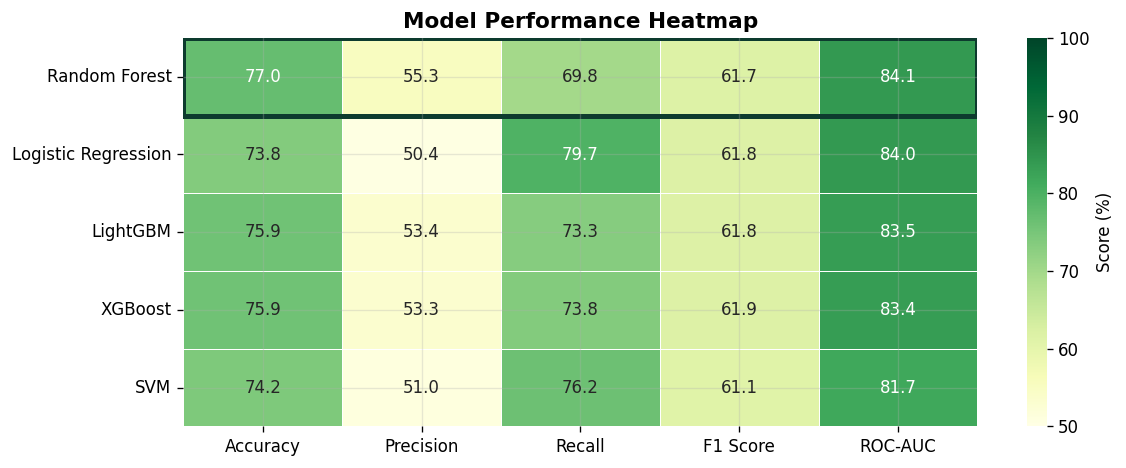

Saved: docs/model_heatmap.png


In [10]:
# Heatmap — best model highlighted with border
heatmap_df = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Score (%)'}, ax=ax,
            vmin=50, vmax=100)
ax.set_title('Model Performance Heatmap', fontsize=13, fontweight='bold')
ax.set_ylabel('')

best_idx = heatmap_df.index.tolist().index(best_name)
ax.add_patch(plt.Rectangle((0, best_idx), len(metrics), 1,
             fill=False, edgecolor=BRAND['dark'], linewidth=3))
plt.tight_layout()
plt.savefig('../docs/model_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: docs/model_heatmap.png')

## 6. Best Model Deep Evaluation

In [11]:
print(f'BEST MODEL: {best_name}')
print('=' * 50)
print(classification_report(y_test, y_pred,
                             target_names=['Retained', 'Churned']))

BEST MODEL: Random Forest
              precision    recall  f1-score   support

    Retained       0.88      0.80      0.84      1035
     Churned       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



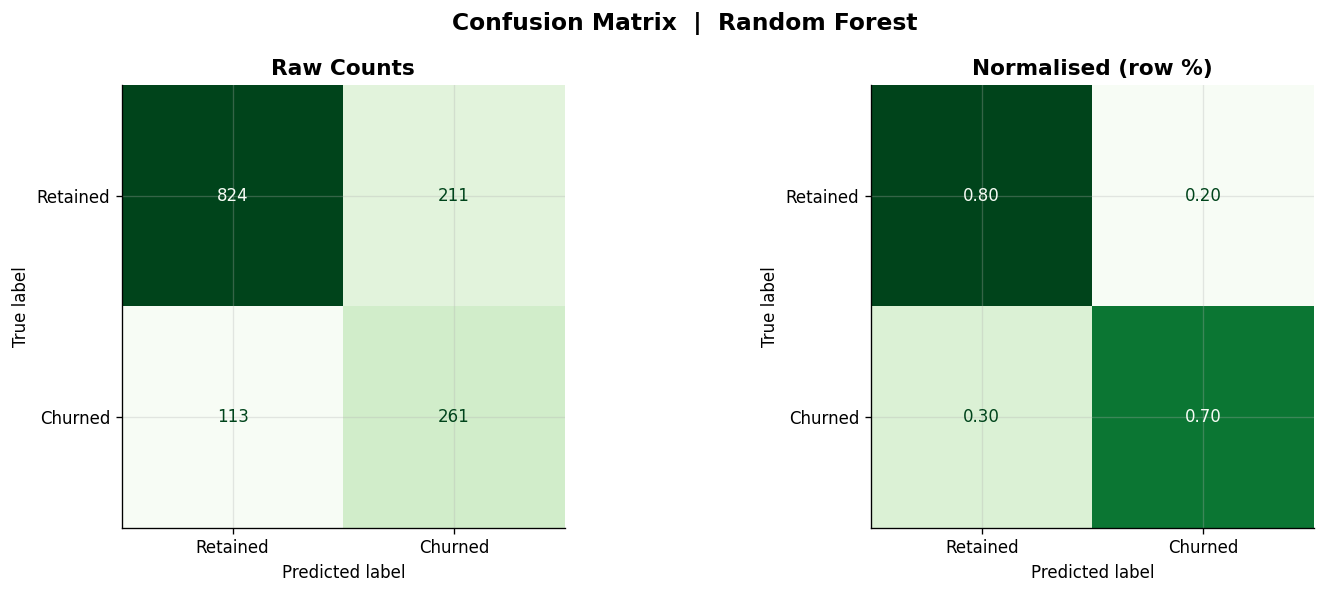

True Positives  (correctly predicted churn):     261
True Negatives  (correctly predicted retained):  824
False Positives (predicted churn, was retained): 211
False Negatives (missed churn — worst outcome):  113

Of all actual churners, model caught : 69.8%
Of all churn alerts raised, correct  : 55.3%


In [12]:
# Confusion matrix — raw and normalised
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Confusion Matrix  |  {best_name}',
             fontsize=14, fontweight='bold')

ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Raw Counts')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm.round(2),
                       display_labels=['Retained','Churned']).plot(
    ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Normalised (row %)')

plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'True Positives  (correctly predicted churn):     {tp:,}')
print(f'True Negatives  (correctly predicted retained):  {tn:,}')
print(f'False Positives (predicted churn, was retained): {fp:,}')
print(f'False Negatives (missed churn — worst outcome):  {fn:,}')
print(f'\nOf all actual churners, model caught : {round(tp/(tp+fn)*100,1)}%')
print(f'Of all churn alerts raised, correct  : {round(tp/(tp+fp)*100,1)}%')

## 7. ROC Curve Comparison

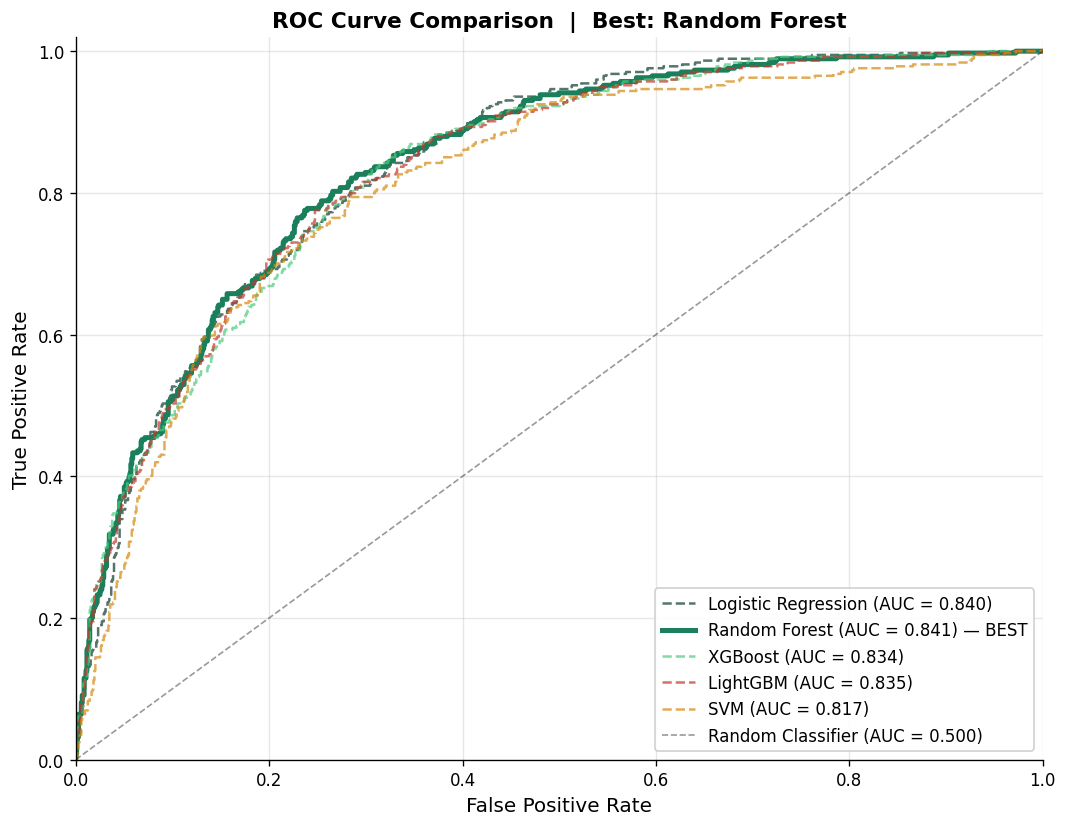

Saved: docs/roc_curves.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

for i, (name, info) in enumerate(trained_models.items()):
    fpr, tpr, _ = roc_curve(y_test, info['y_pred_prob'])
    auc         = roc_auc_score(y_test, info['y_pred_prob'])
    is_best     = (name == best_name)
    ax.plot(fpr, tpr,
            color=PALETTE[i % len(PALETTE)],
            linewidth=3.0 if is_best else 1.5,
            linestyle='-'  if is_best else '--',
            alpha=1.0 if is_best else 0.7,
            label=f'{name} (AUC = {auc:.3f})' + (' — BEST' if is_best else ''))

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4,
        label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title(f'ROC Curve Comparison  |  Best: {best_name}',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../docs/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: docs/roc_curves.png')

## 8. SHAP Explainability

In [14]:
# Use best tree model for SHAP
tree_priority  = ['Random Forest', 'XGBoost', 'LightGBM']
shap_model_name = next(
    (m for m in [best_name] + tree_priority if m in trained_models
     and m not in {'Logistic Regression', 'SVM'}),
    tree_priority[0]
)
shap_model = trained_models[shap_model_name]['model']

# Always use unscaled data for tree SHAP
X_test_df = X_test_clean.copy()

print(f'Computing SHAP values using : {shap_model_name}')
print(f'X_test_df shape             : {X_test_df.shape}')

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_df)

print(f'shap_values type  : {type(shap_values)}')
print(f'shap_values shape : {np.array(shap_values).shape}')

# Handle both 2D (XGBoost/LGBM) and 3D (Random Forest) outputs
sv = np.array(shap_values)
if sv.ndim == 3:
    # Shape (n_samples, n_features, n_classes) — Random Forest
    shap_vals = sv[:, :, 1]              # class 1 = Churned
    exp_val   = float(explainer.expected_value[1])
else:
    # Shape (n_samples, n_features) — XGBoost / LightGBM
    shap_vals = sv
    exp_val   = float(explainer.expected_value)

print(f'shap_vals (class 1) shape : {shap_vals.shape}')
print(f'expected_value            : {exp_val:.4f}')
print('SHAP values ready')

Computing SHAP values using : Random Forest
X_test_df shape             : (1409, 21)
shap_values type  : <class 'numpy.ndarray'>
shap_values shape : (1409, 21, 2)
shap_vals (class 1) shape : (1409, 21)
expected_value            : 0.4995
SHAP values ready


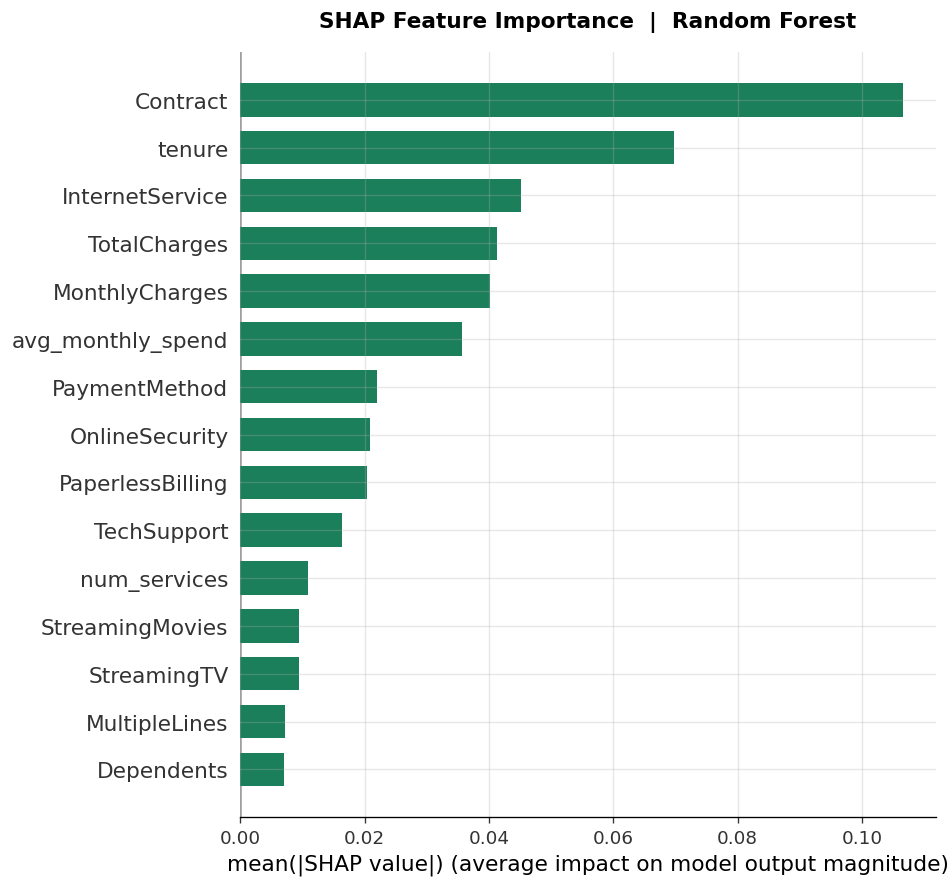

Saved: docs/shap_importance.png


In [15]:
# SHAP Feature Importance Bar
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_df,
                  plot_type='bar', show=False,
                  max_display=15, color=BRAND['primary'])
plt.title(f'SHAP Feature Importance  |  {shap_model_name}',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../docs/shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: docs/shap_importance.png')

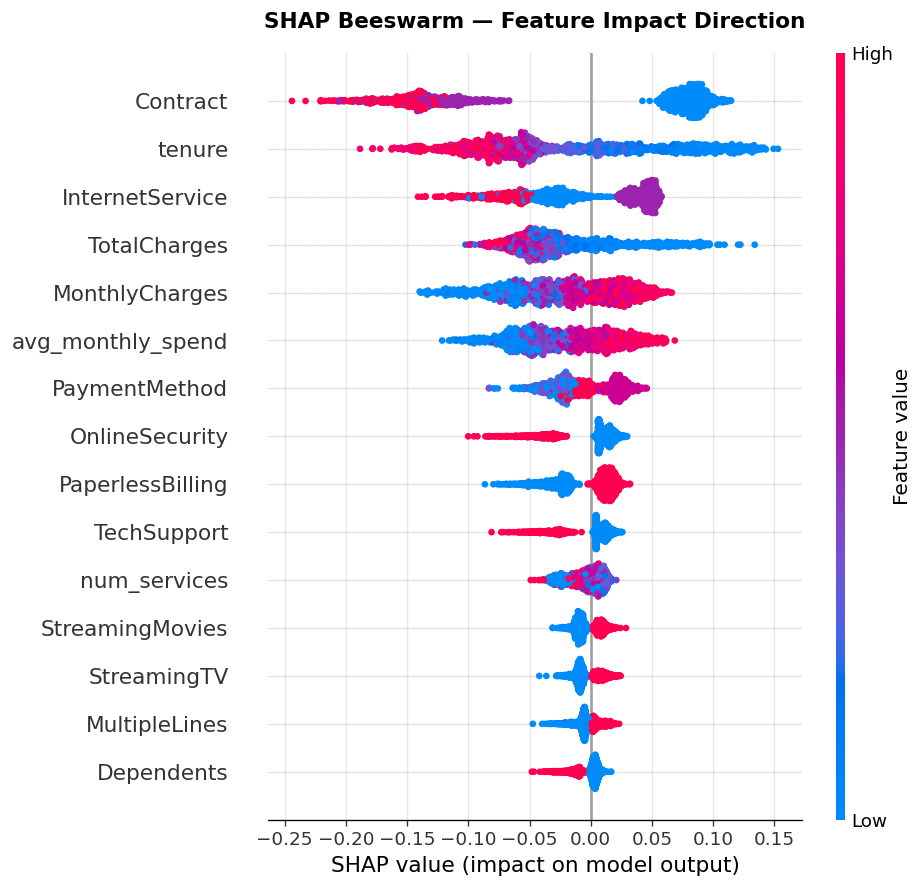

Saved: docs/shap_beeswarm.png


In [16]:
# SHAP Beeswarm — direction of impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_df,
                  show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact Direction',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../docs/shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: docs/shap_beeswarm.png')

Customer index : 0
Actual         : Retained
Predicted      : Retained


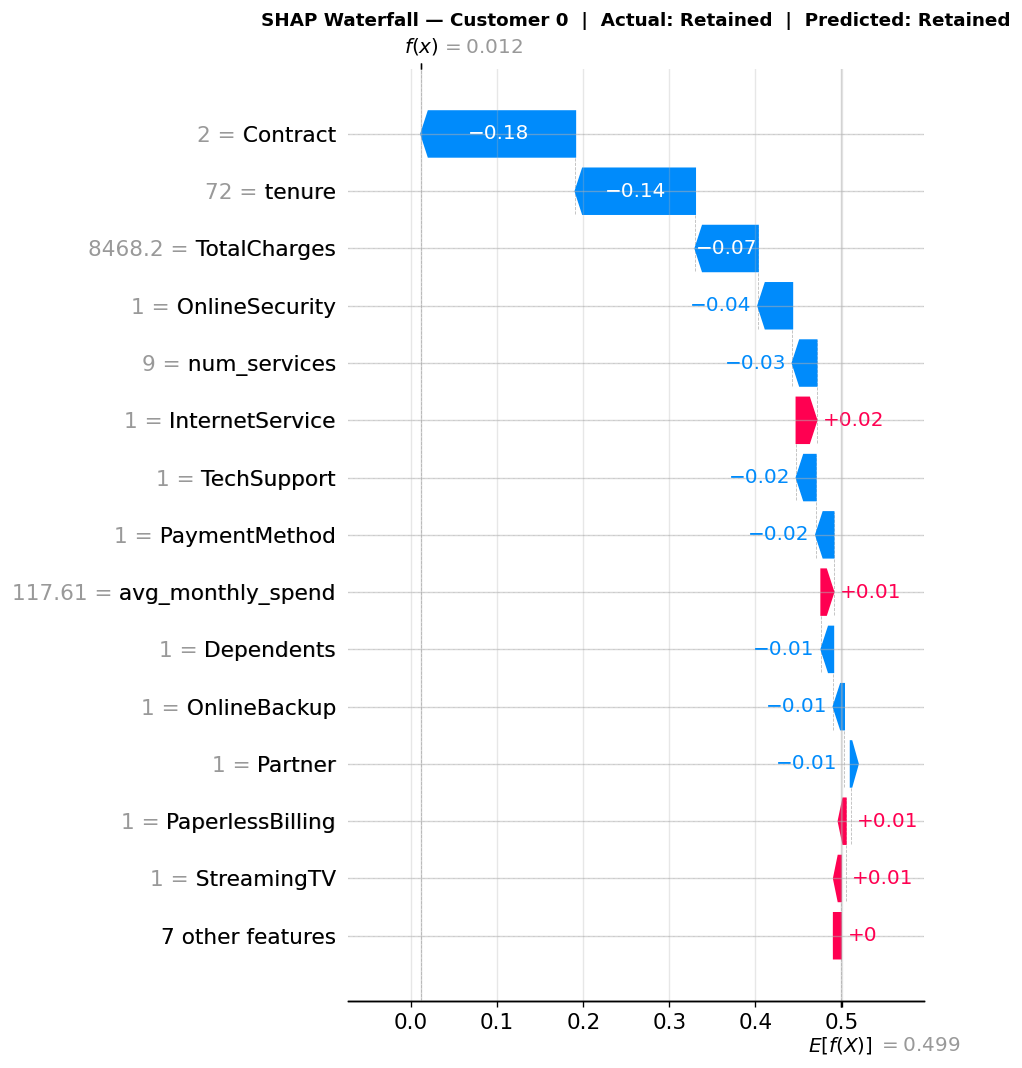

Saved: docs/shap_waterfall.png


In [17]:
# SHAP Waterfall — single customer explanation
sample_idx = 0
actual     = 'Churned'  if y_test.iloc[sample_idx] == 1 else 'Retained'
predicted  = 'Churned'  if trained_models[shap_model_name]['y_pred'][sample_idx] == 1 else 'Retained'

print(f'Customer index : {sample_idx}')
print(f'Actual         : {actual}')
print(f'Predicted      : {predicted}')

shap_explanation = shap.Explanation(
    values        = shap_vals[sample_idx],             # 1D (21,)
    base_values   = exp_val,                           # scalar
    data          = X_test_df.iloc[sample_idx].values, # 1D (21,)
    feature_names = X_test_df.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, show=False, max_display=15)
plt.title(
    f'SHAP Waterfall — Customer {sample_idx}'
    f'  |  Actual: {actual}  |  Predicted: {predicted}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('../docs/shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: docs/shap_waterfall.png')

In [18]:
# Top 10 SHAP features
shap_df = pd.DataFrame({
    'Feature'     : X.columns,
    'Mean |SHAP|' : np.abs(shap_vals).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(10).reset_index(drop=True)
shap_df.index = shap_df.index + 1

print('TOP 10 FEATURES BY SHAP IMPORTANCE')
print('=' * 45)
print(shap_df.to_string())

TOP 10 FEATURES BY SHAP IMPORTANCE
              Feature  Mean |SHAP|
1            Contract     0.106587
2              tenure     0.069822
3     InternetService     0.045109
4        TotalCharges     0.041262
5      MonthlyCharges     0.040124
6   avg_monthly_spend     0.035736
7       PaymentMethod     0.022077
8      OnlineSecurity     0.020865
9    PaperlessBilling     0.020447
10        TechSupport     0.016389


## 9. Save Best Model

In [19]:
os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

model_filename = best_name.lower().replace(' ', '_')
artifacts = {
    f'../models/best_model_{model_filename}.pkl' : best_model,
    '../models/scaler.pkl'                       : scaler,
    '../models/imputer.pkl'                      : imputer,
    '../models/label_encoders.pkl'               : label_encoders,
    '../models/feature_names.pkl'                : list(X.columns),
}
for path, obj in artifacts.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved : {path}')

results_df.to_csv('../reports/model_comparison_results.csv', index=False)
print('Saved : ../reports/model_comparison_results.csv')

shap_df.to_csv('../reports/shap_feature_importance.csv', index=False)
print('Saved : ../reports/shap_feature_importance.csv')

print('\nAll artifacts saved successfully')

Saved : ../models/best_model_random_forest.pkl
Saved : ../models/scaler.pkl
Saved : ../models/imputer.pkl
Saved : ../models/label_encoders.pkl
Saved : ../models/feature_names.pkl
Saved : ../reports/model_comparison_results.csv
Saved : ../reports/shap_feature_importance.csv

All artifacts saved successfully


## 10. Summary and Recommendations

In [20]:
top3 = shap_df.head(3)['Feature'].tolist()

print('WEEK 5 — ML MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f"""
Models Trained    : {len(results_df)}
Best Model        : {best_name}
Selection Metric  : ROC-AUC

Performance:
  Accuracy   : {best_row['Accuracy']}%
  Precision  : {best_row['Precision']}%
  Recall     : {best_row['Recall']}%
  F1 Score   : {best_row['F1 Score']}%
  ROC-AUC    : {best_row['ROC-AUC']}%

Top 3 Churn Drivers (SHAP):
  1. {top3[0]}
  2. {top3[1]}
  3. {top3[2]}

Business Impact:
  Model identifies {best_row['Recall']}% of churners before
  they leave, enabling proactive retention campaigns.

Next Steps:
  Week 6 — Hyperparameter tuning + cross validation
  Week 7 — FastAPI deployment of best model
  Week 8 — ML predictions inside Streamlit dashboard
""")

WEEK 5 — ML MODEL COMPARISON SUMMARY

Models Trained    : 5
Best Model        : Random Forest
Selection Metric  : ROC-AUC

Performance:
  Accuracy   : 77.0%
  Precision  : 55.3%
  Recall     : 69.79%
  F1 Score   : 61.7%
  ROC-AUC    : 84.12%

Top 3 Churn Drivers (SHAP):
  1. Contract
  2. tenure
  3. InternetService

Business Impact:
  Model identifies 69.79% of churners before
  they leave, enabling proactive retention campaigns.

Next Steps:
  Week 6 — Hyperparameter tuning + cross validation
  Week 7 — FastAPI deployment of best model
  Week 8 — ML predictions inside Streamlit dashboard

